## Basic Experiment 

In [1]:
import torch
import numpy as np
from torch import nn
import pandas as pd
import torch

In [12]:
array0 = np.array([1,1,0,0,1,0])
mask = array0 == 0
np.random.choice(np.where(mask)[0])

2

In [16]:
(array1==array0).any()

True

In [13]:
array1= array0.copy()
mask = array0 == 0
array0[np.random.choice(np.where(mask)[0])] = 1
array0,array1

(array([1, 1, 1, 0, 1, 0]), array([1, 1, 0, 0, 1, 0]))

In [48]:
def apply_along_axis(x,function,axis,z=None):
    if isinstance(x,np.ndarray):
        y = torch.from_numpy(x)
    else:
        y=x
    if z is not None:
        res = torch.stack([function(x_i,z[i]) for i, x_i in enumerate(torch.unbind(y, dim=axis), 0)], dim=axis)
    else:
        res = torch.stack([function(x_i) for i, x_i in enumerate(torch.unbind(y, dim=axis), 0)], dim=axis)
    return res

### No recommendation

In [3]:
# Initialize parameters
num_users = 5  # |U|
num_items = 10  # |I|
num_days = 100  # |T|
K = 10  # maximum days of data visibility
lambda_val = 0.5  # weighting factor for utility and privacy

In [ ]:
num_items = 10
target = 10
K = 10
class Player():
    def __init__(self,initial_state=None,target_utility=target):
        self.target_utility = target
        self.state = np.zeros(num_items)
        self.history = 

In [71]:
# Define utility and privacy functions
def utility_function(x_u, X_t):
    # Utility is the dot product of the user's data with all other users' data
    return np.sum([np.dot(x_u, X_t[v]) for v in range(num_users)])

def privacy_function(x_u):
    # Privacy risk is inversely proportional to the number of items shared
    return 100 / np.sum(x_u > 0)

# Reward function combining utility and privacy
def compute_reward(x_u, X_t):
    f_u = utility_function(x_u, X_t)
    g_u = privacy_function(x_u)
    return lambda_val * f_u + (1 - lambda_val) * g_u

# Action logic based on strategy
def take_action(u, current_k, state_u, target_utility, X_t):
    #current_reward = compute_reward(state_u, X_t)
    utility = utility_function(state_u,X_t)
    #privacy_risk = privacy_function(state_u)
    if utility < target_utility and current_k < K:
        return 'add'
    elif utility >= target_utility and current_k > 1:
        return 'subtract'
    else:
        return 'wait'
    
# Update history
def update_history(state_history,new_data):
    state_history = np.concatenate((state_history[1:,:,:],new_data[np.newaxis,:,:]),axis=0)
    return state_history

def generate_new():
    array = np.zeros((num_users, num_items), dtype=int)
    num_entries = 10
    indices = np.random.choice(num_users * num_items, size=num_entries, replace=False)
    array.flat[indices] = np.random.randint(1, 6, size=num_entries)
    return array

def latest_nonzero(vector):
    nonzero_values = vector[vector != 0]  # Get nonzero values in the column
    if len(nonzero_values) > 0:
        return nonzero_values[-1]  # Take the latest (last) nonzero value
    else:
        return torch.tensor(0)  # No nonzero value, so set to 0

def filtering(state_history_u,current_ks_u):
    temp = state_history_u[-current_ks_u:,:]
    #print(temp)
    return apply_along_axis(temp,latest_nonzero,axis=-1)

def current_state(state_history,current_ks):
    return torch.transpose(apply_along_axis(state_history,filtering,axis=1,z=current_ks),0,1)

def update_states(state_history,current_ks):
    new_data = generate_new()
    state_history = update_history(state_history,new_data)
    current_states = current_state(state_history,current_ks)
    return state_history,current_states.cpu().numpy()
    

In [78]:
import numpy as np
import torch

# Initialize the states x^0_u for each user with random preferences (ratings)
results = []
# Each user has a vector of ratings between 1 and 5 for 10 items
state_history = np.array([generate_new() for i in range(3)])
#states = np.random.randint(1, 6, size=(num_users, num_items))  # initial data for day 0
current_ks = np.random.randint(1, K+1, size=num_users)  # initial K values for each user
states = current_state(state_history,current_ks).cpu().numpy()
target_utilities = np.random.uniform(1, 125, size=num_users)  # random target utilities for each user

# Simulation over 100 days
for day in range(1, num_days+1):
    print(f"Day {day}")
    for u in range(num_users):
        X_t = states  # stacked user states at day t
        action = take_action(u, current_ks[u], states[u], target_utilities[u], X_t)
        
        if action == 'add' and current_ks[u] < K:
            current_ks[u] += 1  # Increase K by 1
        elif action == 'subtract' and current_ks[u] > 1:
            current_ks[u] -= 1  # Decrease K by 1
        
        # # Update the visible data for the user (only the last K days of data are visible)
        # visible_data = np.random.randint(1, 6, size=num_items)  # simulate new ratings added for the day
        # states[u] = visible_data  # In practice, only last K days of data should be used
    state_history,states = update_states(state_history,current_ks)


    # Print current K values and rewards for all users
    for u in range(num_users):
        utility = utility_function(states[u],states)
        privacy = privacy_function(states[u])
        reward = compute_reward(states[u], states)
        results.append({'day':day,'user':u,'utility':utility,'privacy':privacy,'reward':reward})
        print(f"User {u}: K = {current_ks[u]}, utility = {utility:.2f}, privacy = {privacy:.2f},Reward = {reward:.2f}")
    print("\n")


Day 1
User 0: K = 2, utility = 71.00, privacy = 20.00,Reward = 45.50
User 1: K = 1, utility = 8.00, privacy = 100.00,Reward = 54.00
User 2: K = 4, utility = 95.00, privacy = 33.33,Reward = 64.17
User 3: K = 1, utility = 86.00, privacy = 33.33,Reward = 59.67
User 4: K = 1, utility = 36.00, privacy = 33.33,Reward = 34.67


Day 2
User 0: K = 1, utility = 68.00, privacy = 50.00,Reward = 59.00
User 1: K = 2, utility = 25.00, privacy = 50.00,Reward = 37.50
User 2: K = 3, utility = 52.00, privacy = 33.33,Reward = 42.67
User 3: K = 1, utility = 62.00, privacy = 50.00,Reward = 56.00
User 4: K = 2, utility = 71.00, privacy = 20.00,Reward = 45.50


Day 3
User 0: K = 1, utility = 12.00, privacy = 100.00,Reward = 56.00
User 1: K = 3, utility = 37.00, privacy = 20.00,Reward = 28.50
User 2: K = 4, utility = 42.00, privacy = 25.00,Reward = 33.50
User 3: K = 1, utility = 0.00, privacy = inf,Reward = inf
User 4: K = 1, utility = 34.00, privacy = 50.00,Reward = 42.00


Day 4
User 0: K = 2, utility = 18.0

/var/folders/cx/ykyfm0qs65b571x6zq2_7dm40000gn/T/ipykernel_16879/2001375734.py:8: RuntimeWarning: divide by zero encountered in scalar divide
  return 100 / np.sum(x_u > 0)


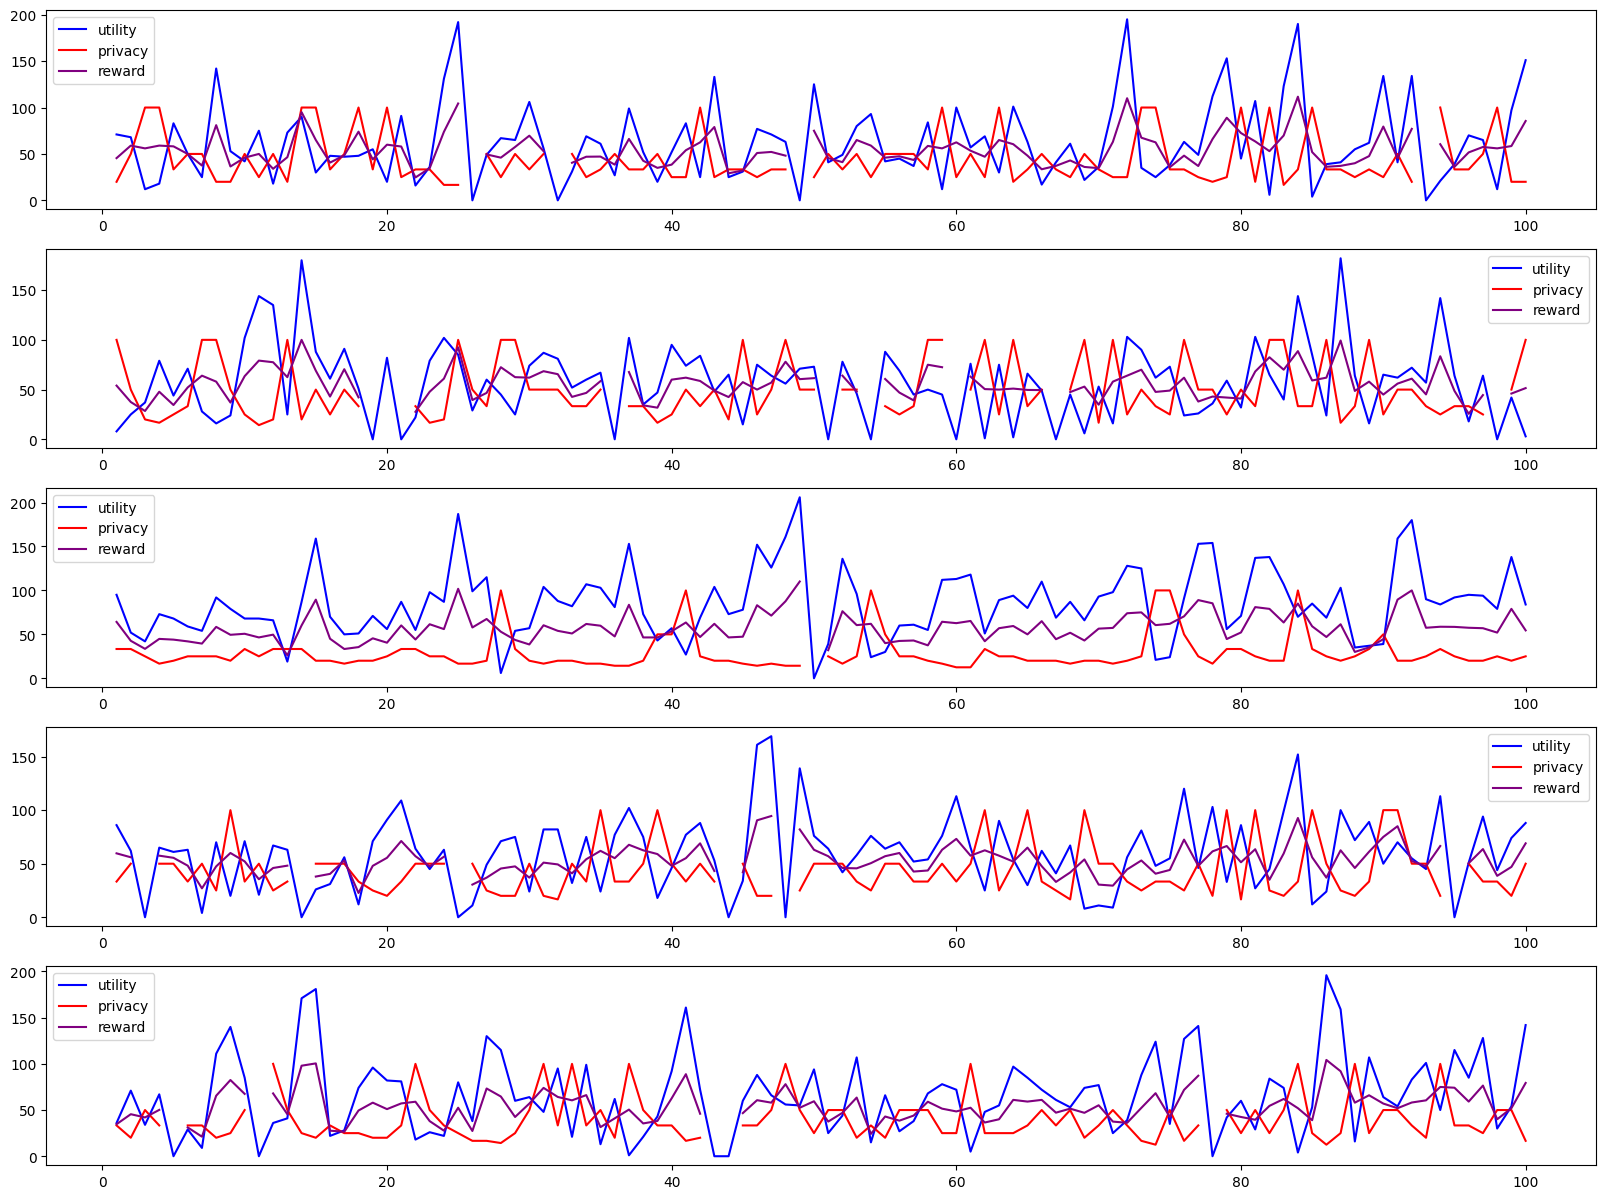

In [79]:
import matplotlib.pyplot as plt
df = pd.DataFrame(results)

fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(20, 15))

for i in range(5):
    subset = df[df['user'] == i]
    ax = axes[i]
    ax.plot(subset['day'],subset['utility'],color='b',label='utility')
    ax.plot(subset['day'],subset['privacy'],color='r',label='privacy')
    ax.plot(subset['day'],subset['reward'],color='purple',label='reward')
    ax.legend()

### Surprise

In [ ]:
pip install scikit-surprise

In [3]:
from surprise import SVD, Dataset, Reader
from surprise.model_selection import train_test_split

# Example dataset: user-item ratings
ratings_dict = {
    "item": [1, 2, 3, 1, 2, 3],
    "user": [9, 32, 2, 45, 32, 4],
    "rating": [3, 2, 4, 3, 1, 5],
}
df = pd.DataFrame(ratings_dict)

# Load the dataset
reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(df[['user', 'item', 'rating']], reader)
trainset, testset = train_test_split(data, test_size=0.25)

# FunkSVD model
algo = SVD()
algo.fit(trainset)

# Predict on the test set
predictions = algo.test(testset)


### Pytorch

#### Recommender Algorithm

In [4]:
# FunkSVD model
class FunkSVD(nn.Module):
    def __init__(self, num_users, num_items, latent_dim):
        super(FunkSVD, self).__init__()
        self.user_factors = nn.Embedding(num_users, latent_dim)
        self.item_factors = nn.Embedding(num_items, latent_dim)
        self.user_factors.weight.data.uniform_(-0.01, 0.01)
        self.item_factors.weight.data.uniform_(-0.01, 0.01)

    def forward(self, user_ids, item_ids):
        user_embedding = self.user_factors(user_ids)
        item_embedding = self.item_factors(item_ids)
        return (user_embedding * item_embedding).sum(1)

# Training function for FunkSVD
def train_svd(model, optimizer, ratings, user_ids, item_ids, epochs=10):
    loss_fn = nn.MSELoss()
    for epoch in range(epochs):
        optimizer.zero_grad()
        preds = model(user_ids, item_ids)
        loss = loss_fn(preds, ratings)
        loss.backward()
        optimizer.step()
    return model


#### Reward and Penalty Computation

In [1]:
def hr_at_5(user_ratings, predicted_ratings):
    # Get top 5 predicted movie ratings
    top_5_predicted = np.argsort(predicted_ratings)[-5:]
    # Get actual watched movies
    actual_movies = np.where(user_ratings > 0)[0]
    # Calculate hits
    hits = len(set(top_5_predicted).intersection(set(actual_movies)))
    return hits / 5

def compute_penalty(K, max_data):
    return K / max_data  # You can use a more complex function if needed

def compute_reward(user_ratings, predicted_ratings, K, max_data):
    reward = hr_at_5(user_ratings, predicted_ratings)
    penalty = compute_penalty(K, max_data)
    return reward - penalty


#### Simulation

In [ ]:
num_users = 10
num_movies = 10
latent_dim = 5
epochs = 10
days = 100

# Initializing the FunkSVD model
svd_model = FunkSVD(num_users, num_movies, latent_dim)
optimizer = torch.optim.Adam(svd_model.parameters(), lr=0.01)

# Agent data
K_values = np.random.randint(1, 10, size=num_users)
ratings = np.random.randint(0, 5, size=(num_users, num_movies))  # User-movie rating matrix

# Simulate for 100 days
for day in range(days):
    for user in range(num_users):
        # Fit model to data
        visible_ratings = ratings[user, :K_values[user]]
        user_ids = torch.tensor([user] * len(visible_ratings))
        item_ids = torch.tensor(range(len(visible_ratings)))
        ratings_tensor = torch.tensor(visible_ratings, dtype=torch.float32)
        
        svd_model = train_svd(svd_model, optimizer, ratings_tensor, user_ids, item_ids, epochs)
        
        # Make predictions
        predicted_ratings = svd_model(user_ids, item_ids).detach().numpy()

        # Compute reward and penalty
        reward = compute_reward(ratings[user], predicted_ratings, K_values[user], max_data=10)
        
        # Adjust K based on reward and penalty
        if reward < desired_boundary[user]:
            K_values[user] = max(1, K_values[user] - 1)  # Decrease K
        else:
            K_values[user] = min(10, K_values[user] + 1)  # Increase K

    print(f"Day {day + 1} completed.")
